### confusion matrices

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from matplotlib.colors import TwoSlopeNorm

In [2]:
def create_confusion_matrix(data, species):
    """
    Creates a confusion matrix from detection results using GT derived from filename.

    Args:
        data: list of results entries from results.json
        species: list of species names in order of class indices

    Returns:
        cm: (num_classes + 1) x (num_classes + 1) confusion matrix
            Rows = ground truth classes
            Columns = predicted classes
            Last row = background FP
            Last column = missed GT (FN)
    """
    num_classes = len(species)
    cm = np.zeros((num_classes + 1, num_classes + 1), dtype=int)

    for entry in data:
        filename = entry["filename"]
        # Derive GT class from filename; fallback to last index if unknown
        row_index = next((i for i, sp in enumerate(species) if filename.startswith(sp)), num_classes)

        # True positives (correct predictions)
        for cls_id in entry["true_positives"]["classes"]:
            cm[row_index, cls_id] += 1

        # False negatives (missed GT objects)
        cm[row_index, num_classes] += len(entry["false_negatives"]["classes"])

        # False positives
        for cls_id in entry["false_positives"]["classes"]:
            if cls_id == row_index:
                # Background FP (wrong location for correct class)
                cm[num_classes, cls_id] += 1
            else:
                # Misclassification (wrong class)
                cm[row_index, cls_id] += 1

    return cm

def normalize_confusion_matrix(cm, axis=1):
    """
    Normalize a confusion matrix.

    Parameters
    ----------
    cm : list[list[int]] or np.ndarray
        The confusion matrix.
    axis : int
        Axis to normalize over:
        - 1 = rows (normalize by true class → each row sums to 1)
        - 0 = columns (normalize by predicted class → each column sums to 1)
        - None = normalize by total sum

    Returns
    -------
    np.ndarray
        Normalized confusion matrix (float values).
    """
    cm = np.array(cm, dtype=float)
    if axis is None:
        total = cm.sum()
        return cm / total if total > 0 else cm
    else:
        sums = cm.sum(axis=axis, keepdims=True)
        sums[sums == 0] = 1 
 # avoid division by zero
        return cm / sums
    
def plot_confusion_matrix(cm, species, output_path=None):

    # assume confusion_matrix and labels are already defined
    labels = species + ["background"]
    df = pd.DataFrame(cm, index=labels, columns=labels)

    plt.figure(figsize=(8, 6))
    plt.imshow(df, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()

    # tick labels
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)

    # annotate counts
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, df.iat[i, j],
                    ha="center", va="center",
                    color="white" if df.iat[i, j] > df.values.max()/2 else "black")

    plt.ylabel("True Species")
    plt.xlabel("Predicted Species")
    plt.tight_layout()
    if output_path: plt.savefig(output_path)
    plt.show()




def give_confusion_infos(file, output_path=None):
    with open(file, "r") as f:
        data = json.load(f)

    species = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]
    cm = create_confusion_matrix(data, species)

    print("Confusion Matrix with FP/FN (last row = FP, last col = FN):\n", cm)

    # Row-normalized (recall per class)
    norm_cm_row = normalize_confusion_matrix(cm, axis=1)
    # Column-normalized (precision per class)
    norm_cm_col = normalize_confusion_matrix(cm, axis=0)

    labels = species + ["background"]

    # ✅ use constrained_layout to avoid tight_layout warning
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, norm_cm, title in zip(
        axes,
        [norm_cm_row, norm_cm_col],
        ["Row-normalized (Recall per class)", "Column-normalized (Precision per class)"]
    ):
        df = pd.DataFrame(np.round(norm_cm, 2), index=labels, columns=labels)
        im = ax.imshow(df, interpolation="nearest", cmap="Blues")
        ax.set_title(title)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_ylabel("True Species")
        ax.set_xlabel("Predicted Species")

        # annotate cells
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(
                    j, i, f"{df.iat[i, j]:.2f}",
                    ha="center", va="center",
                    color="white" if df.iat[i, j] > df.values.max()/2 else "black",
                    fontsize=8
                )

    # shared colorbar (works fine with constrained_layout)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Normalized Value")
    if output_path: plt.savefig(output_path)
    plt.show()
    return norm_cm_row, norm_cm_col


In [3]:
def plot_confusion_matrix_differences(norm_cm_row_1, norm_cm_row_2,
                                      norm_cm_col_1, norm_cm_col_2,
                                      species, output_path = None):
    """
    Plot the differences between two sets of normalized confusion matrices
    (row- and column-normalized) with intuitive coloring:

    - Diagonal ↑ = green (improvement), ↓ = red (worse)
    - Off-diagonal ↑ = red (worse), ↓ = green (improvement)
    - Color range automatically scaled to actual data range
    """

    labels = species + ["background"]

    # Compute differences
    diff_row = np.round(norm_cm_row_2 - norm_cm_row_1, 3)
    diff_col = np.round(norm_cm_col_2 - norm_cm_col_1, 3)

    # Make figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, diff_cm, title in zip(
        axes,
        [diff_row, diff_col],
        ["Δ Row-normalized (Recall change)", "Δ Column-normalized (Precision change)"]
    ):
        df = pd.DataFrame(diff_cm, index=labels, columns=labels)

        # Invert off-diagonal meaning (since increases in misclassifications are bad)
        adjusted = df.copy()
        for i in range(len(labels)):
            for j in range(len(labels)):
                if i != j:
                    adjusted.iat[i, j] = -adjusted.iat[i, j]

        # Compute color limits dynamically
        vmin, vmax = adjusted.values.min(), adjusted.values.max()
        vlim = max(abs(vmin), abs(vmax))  # symmetric around zero

        # Use a centered diverging colormap: red↔white↔green
        norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)
        im = ax.imshow(adjusted, interpolation="nearest", cmap="RdYlGn", norm=norm)

        ax.set_title(title)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_ylabel("True Species")
        ax.set_xlabel("Predicted Species")

        # Annotate numeric values (+/-)
        for i in range(len(labels)):
            for j in range(len(labels)):
                val = df.iat[i, j]
                if abs(val) > 0.005:
                    ax.text(
                        j, i, f"{val:+.2f}",
                        ha="center", va="center",
                        color="black",
                        fontsize=8
                    )

    # Shared colorbar
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Green = improvement, Red = degradation", rotation=270, labelpad=20)
    if output_path: plt.savefig(output_path)
    plt.show()


species = ["BRAIIM", "LIRIBO", "FRANOC", "TRIAVA"]


### train4 supervised validation

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 804    9    1    0  193]
 [   6 1014   14    2   40]
 [   1    5  506    4  233]
 [   0    1    2 1179  298]
 [  81   51  149  138    0]]


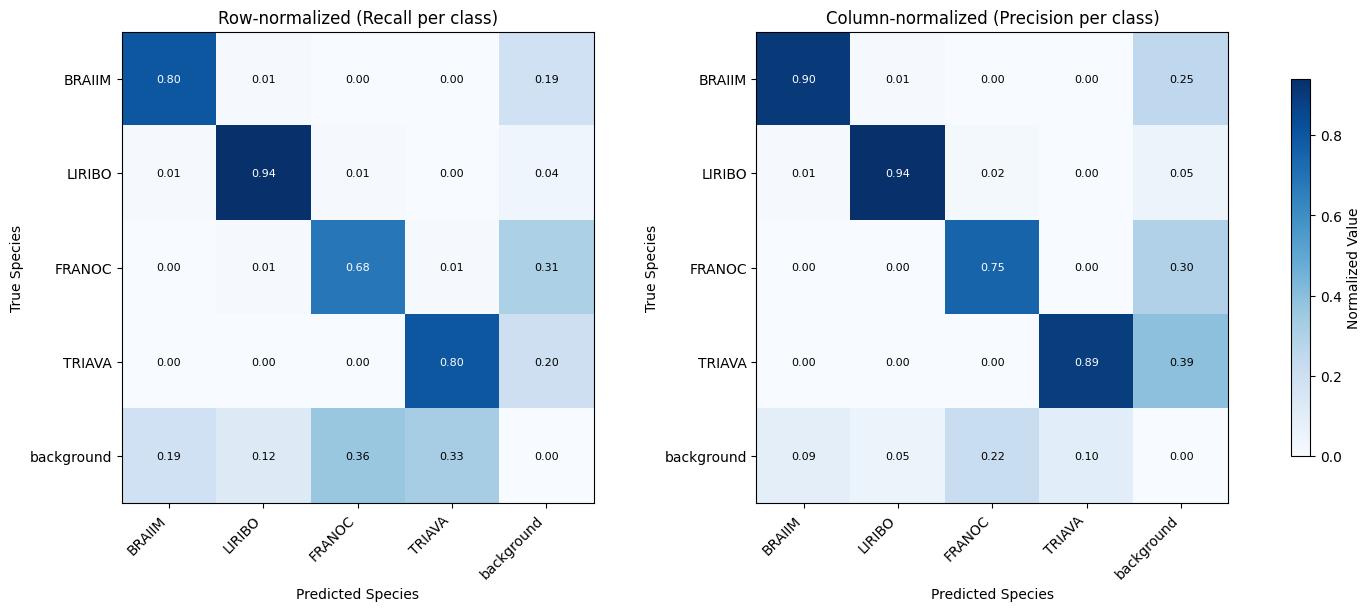

In [15]:
file = "/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train4/results.json"
c1,c2 = give_confusion_infos(file, output_path = "/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train4/confusions.png")

### train 6 supervised validation

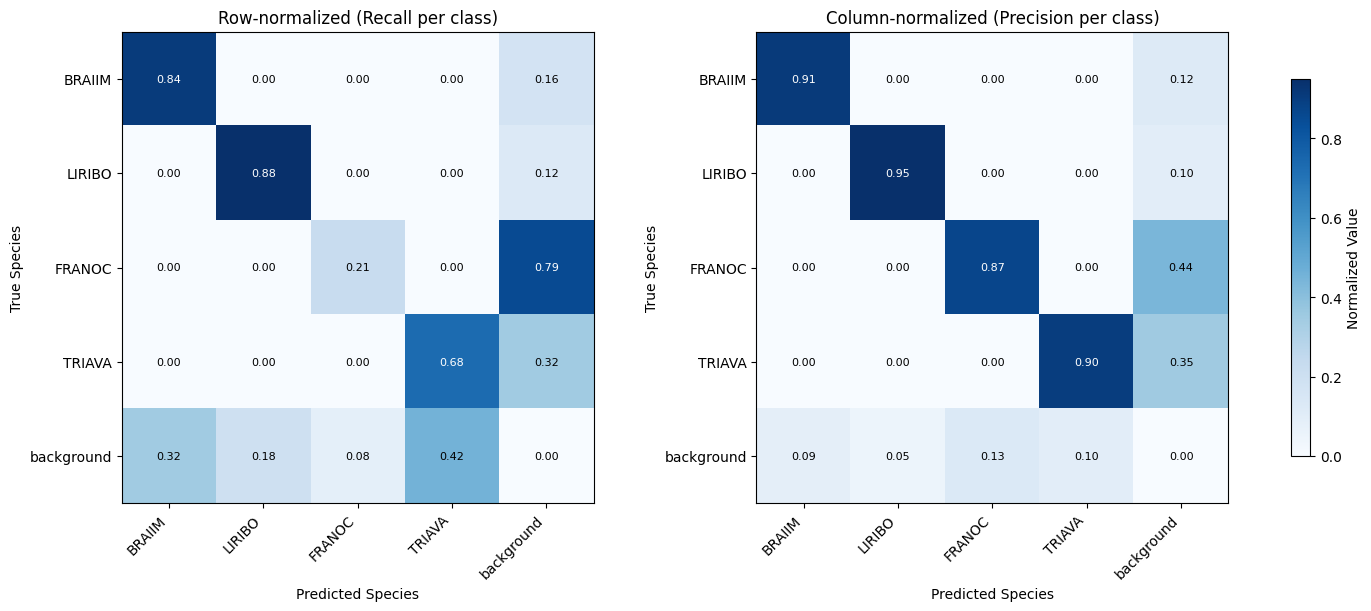

In [16]:
cm = [[838,1,0,0,86], [1,923,0,0,49], [0,0,154,0,23], [0,0,0,1008,114],[158,130,585,469,0]]
cm = [[838,1,0,0,158], [1,923,0, 0,130], [0,0,154,0,585], [0,0,0,1008,469], [86,49,23,114,0]]
# Row-normalized (recall per class)
norm_cm_row = normalize_confusion_matrix(cm, axis=1)
# Column-normalized (precision per class)
norm_cm_col = normalize_confusion_matrix(cm, axis=0)

labels = species + ["background"]

# ✅ use constrained_layout to avoid tight_layout warning
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, norm_cm, title in zip(
    axes,
    [norm_cm_row, norm_cm_col],
    ["Row-normalized (Recall per class)", "Column-normalized (Precision per class)"]
):
    df = pd.DataFrame(np.round(norm_cm, 2), index=labels, columns=labels)
    im = ax.imshow(df, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_ylabel("True Species")
    ax.set_xlabel("Predicted Species")

    # annotate cells
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(
                j, i, f"{df.iat[i, j]:.2f}",
                ha="center", va="center",
                color="white" if df.iat[i, j] > df.values.max()/2 else "black",
                fontsize=8
            )

# shared colorbar (works fine with constrained_layout)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Normalized Value")
plt.savefig("/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train6/confusion.png")
plt.show()

### train4 supervised test set

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1256   32    1    0  323]
 [  14 1179   14    7   80]
 [   1    5  765    4  413]
 [   0    0    5 2076  545]
 [  94   53  186   98    0]]


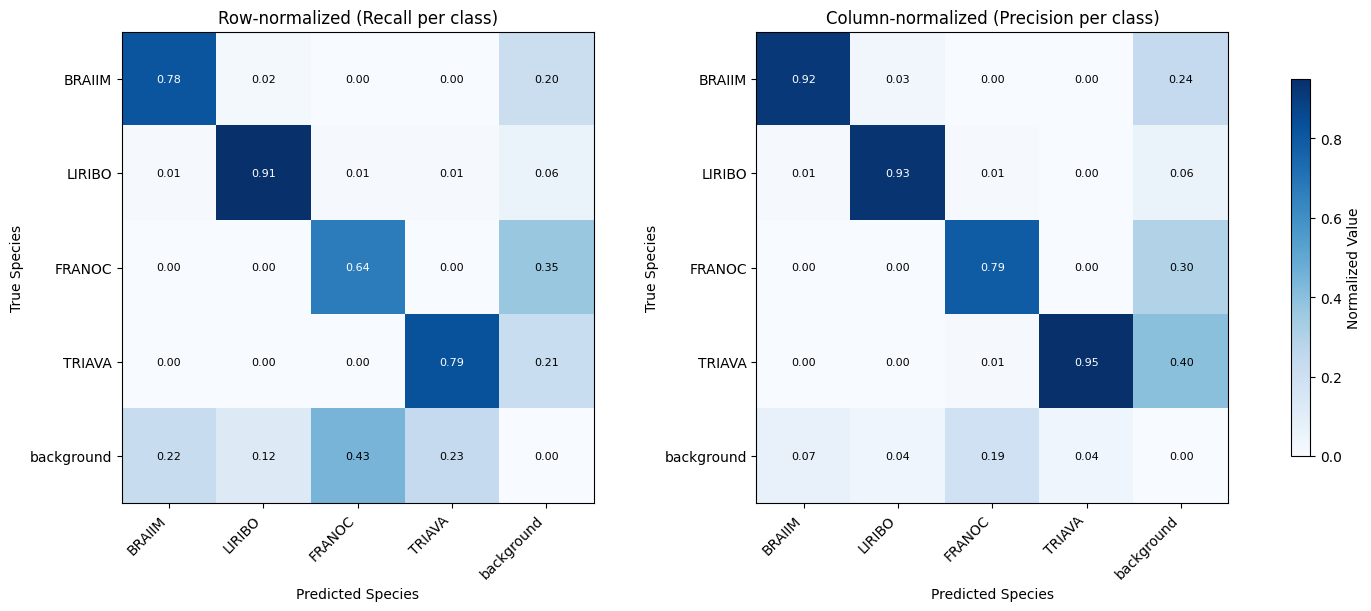

In [18]:
file = "/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train4_test_set/results.json"
c1,c2 = give_confusion_infos(file, output_path = "/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train4_test_set/confusions.png")


### train 6 supervised on test set

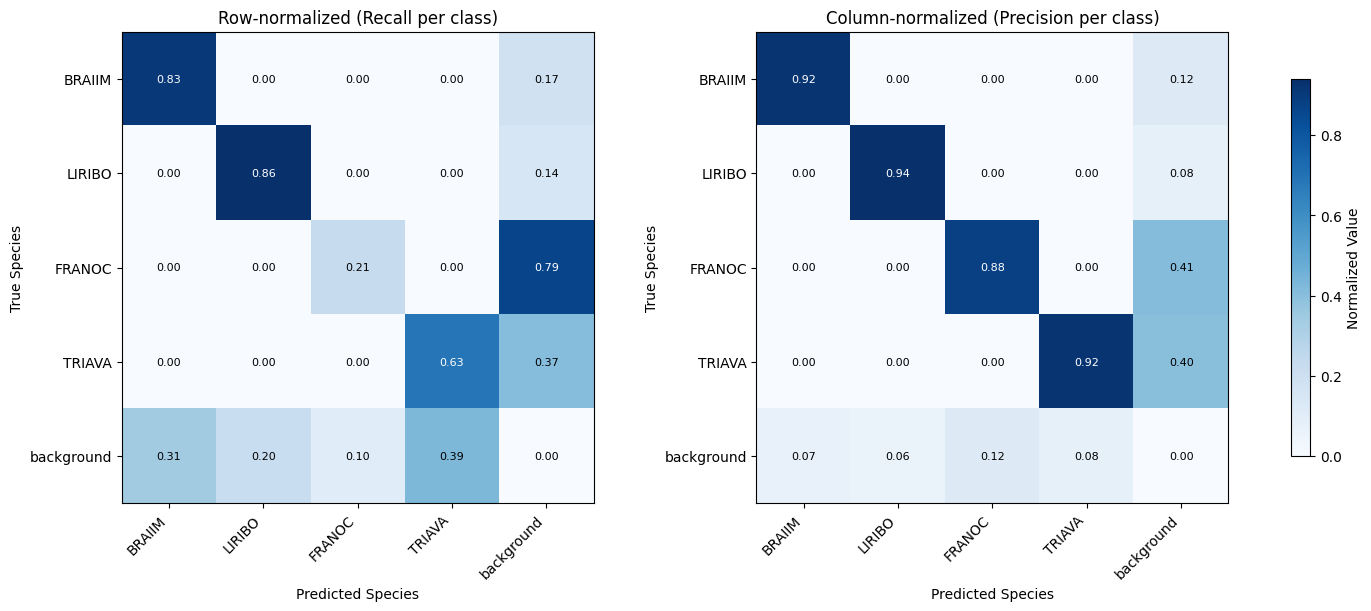

In [20]:
cm = [[1308,0,0,0,271], [2,1080,0,0,177], [0,0,255,0,953], [0,0,0,1638, 948], [106,71,36,134,0]]
# Row-normalized (recall per class)
norm_cm_row = normalize_confusion_matrix(cm, axis=1)
# Column-normalized (precision per class)
norm_cm_col = normalize_confusion_matrix(cm, axis=0)

labels = species + ["background"]

# ✅ use constrained_layout to avoid tight_layout warning
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, norm_cm, title in zip(
    axes,
    [norm_cm_row, norm_cm_col],
    ["Row-normalized (Recall per class)", "Column-normalized (Precision per class)"]
):
    df = pd.DataFrame(np.round(norm_cm, 2), index=labels, columns=labels)
    im = ax.imshow(df, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_ylabel("True Species")
    ax.set_xlabel("Predicted Species")

    # annotate cells
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(
                j, i, f"{df.iat[i, j]:.2f}",
                ha="center", va="center",
                color="white" if df.iat[i, j] > df.values.max()/2 else "black",
                fontsize=8
            )

# shared colorbar (works fine with constrained_layout)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Normalized Value")
plt.savefig("/user/christoph.wald/u15287/insect_pest_detection/3_1_supervised_training_evaluation/metrics/train6/confusion_test_set.png")
plt.show()

### Quality of image processed pseudo labels measured against ground truth
low recall, but ok precision

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 605    0    0    0  625]
 [   0  645    0    0  473]
 [   0    0    0    0    0]
 [   0    0    0  822 1615]
 [ 163   88    0  194    0]]


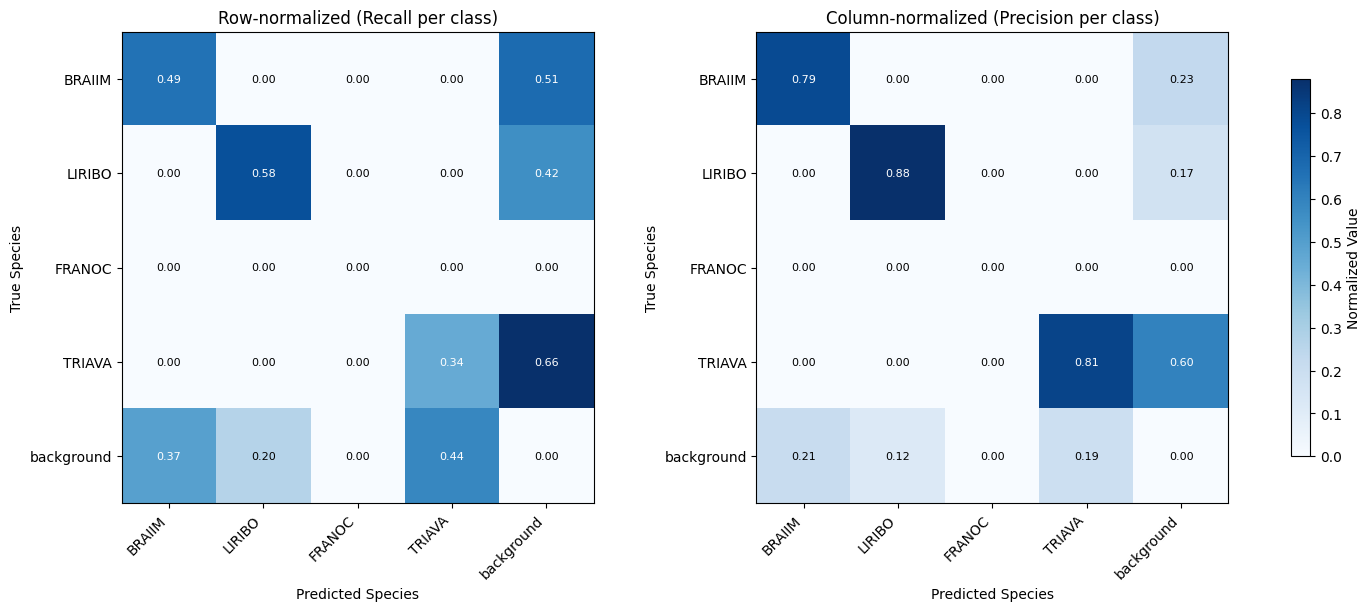

In [10]:
#Test image processing on test set
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/image_procv2.json"
c1, c2 = give_confusion_infos(file, output_path = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/image_procv2_vs_testset.png")

### Quality of model trained on these pseudo labels measured against ground truth
recall improved, precision changed somewhat

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1045   63    0    0  534]
 [  41 1029    0    5  230]
 [   0    0    0    0    0]
 [   5   42    0  771 1850]
 [ 190  192    0   36    0]]


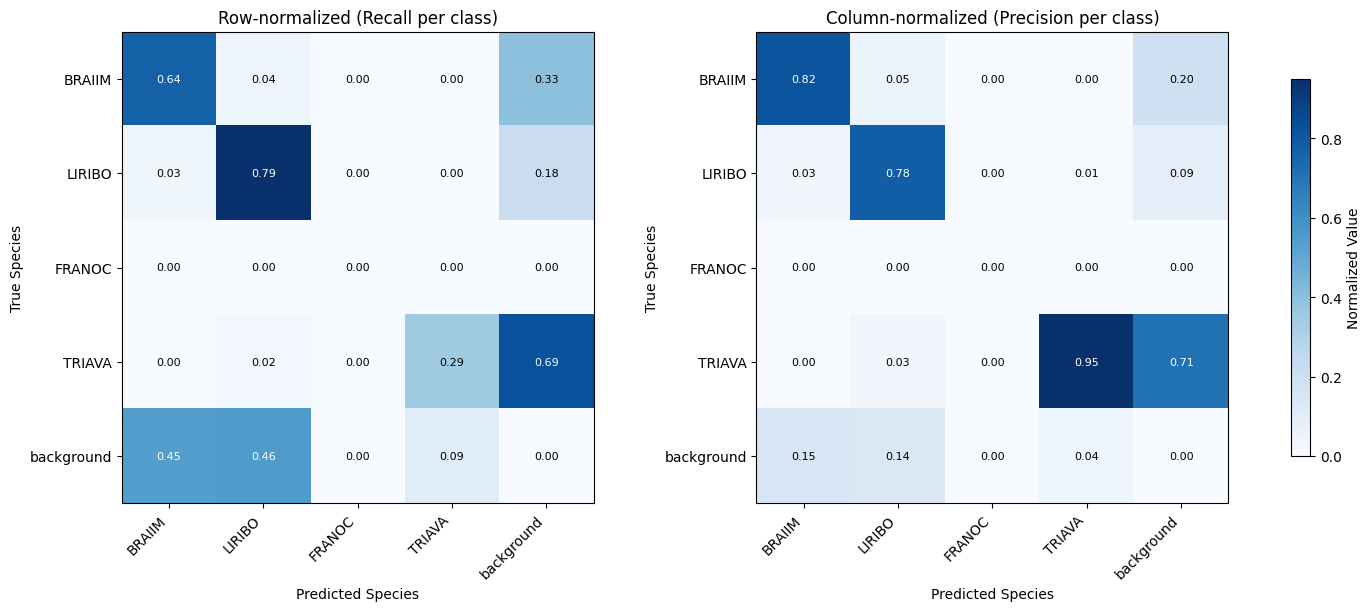

In [11]:
#test results of first iteration
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/first_iteration_train9.json"
c3, c4 = give_confusion_infos(file, output_path="/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/first_iteration_train9_vs_testset.png")

### Quality of model trained on the pseudo labels measure against image processed test set labels
high recall: sticks to the pseudo labels

lowered precision: did not stick to the pseudo label rules? (and compare precision on ground truth: these are sensical rules)

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[665  60   0   0 103]
 [ 38 669   0   4  64]
 [  0   0   0   0   0]
 [  6  48   0 436 580]
 [415 422   0 255   0]]


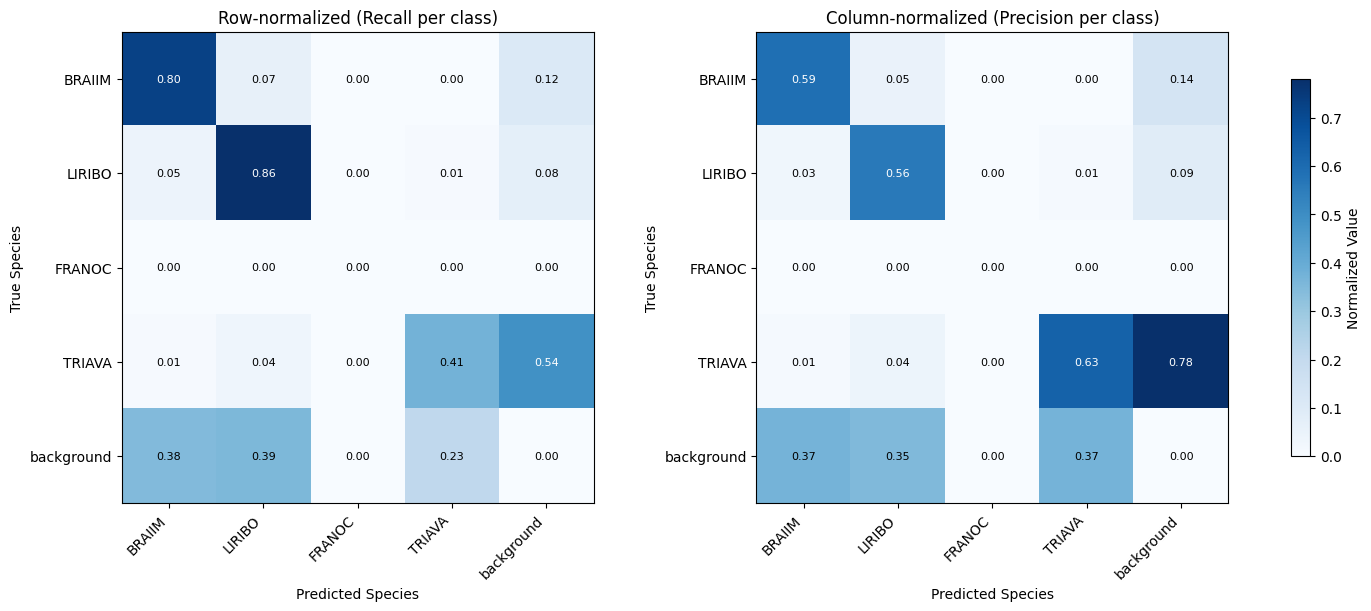

In [12]:
#test results of first iteration
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/first_iteration_train9_on_pseudolabeled_testset.json"
c5, c6 = give_confusion_infos(file, output_path = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/first_iteration_train9_vs_pseudolabeled_testset.png")

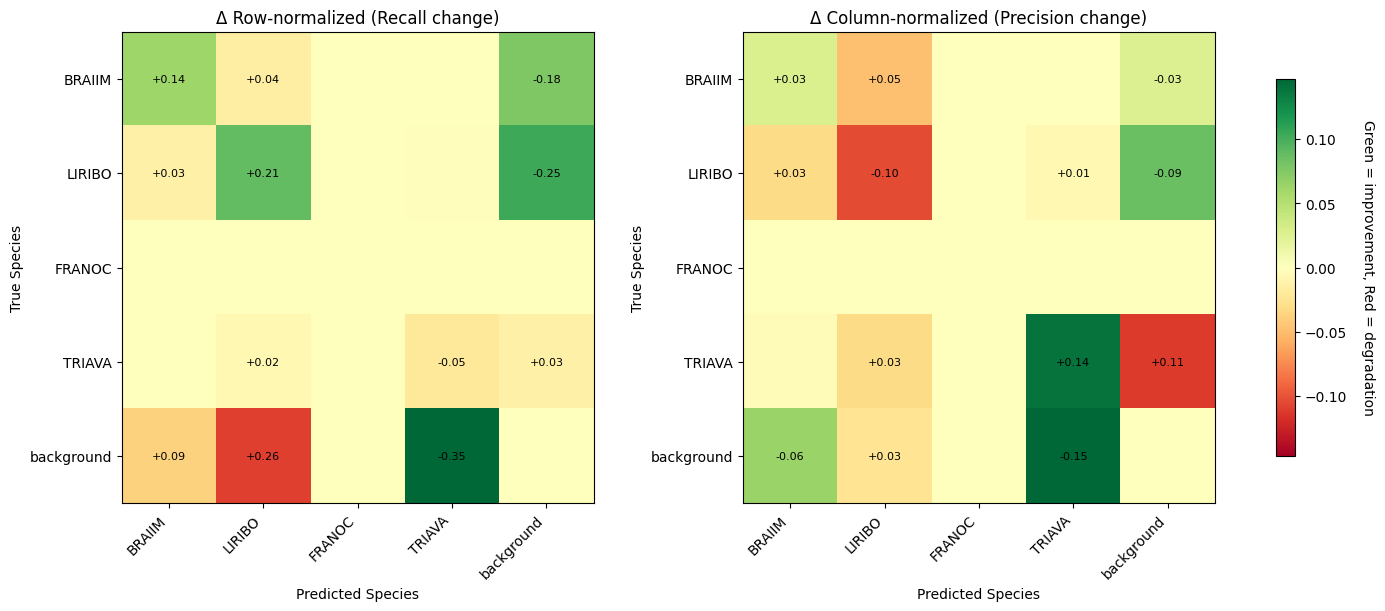

In [ ]:
#Difference of segmented labels and first training
plot_confusion_matrix_differences(c1,c3, c2, c4, species, 
                                  output_path="/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/03_imag_proc_vs_first.png")

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 961   59    0    6  618]
 [  11 1016    0   13  243]
 [   0    0    0    0    0]
 [   1   14    0  747 1874]
 [ 152  119    0   47    0]]


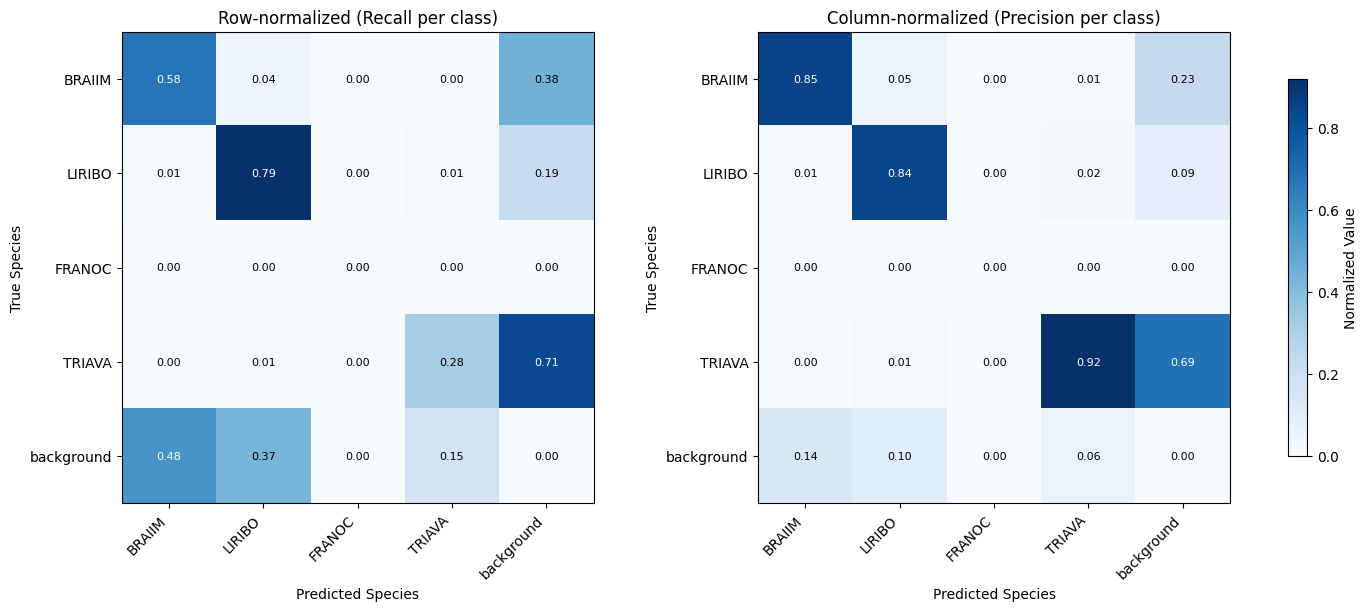

In [ ]:
#test results of second iteration unweighted
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/second_iteration_unweighted_train1.json"
c1,c2 = give_confusion_infos(file)

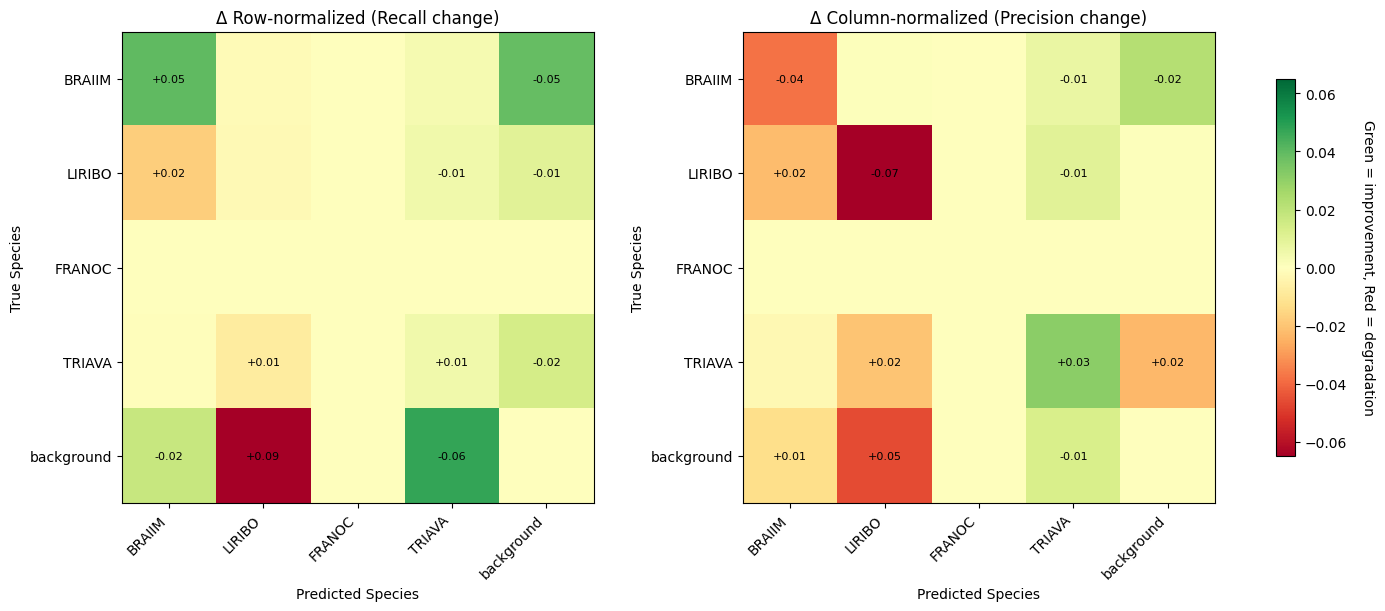

In [ ]:
#Difference of irst training and unweighted second
plot_confusion_matrix_differences(c1,c3, c2, c4, species, 
                                  output_path="/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/04a_second_vs_first_unweighted.png")

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 990   37    0    4  589]
 [  12  995    0   20  264]
 [   0    0    0    0    0]
 [   1    8    0  894 1727]
 [ 178   98    0   92    0]]


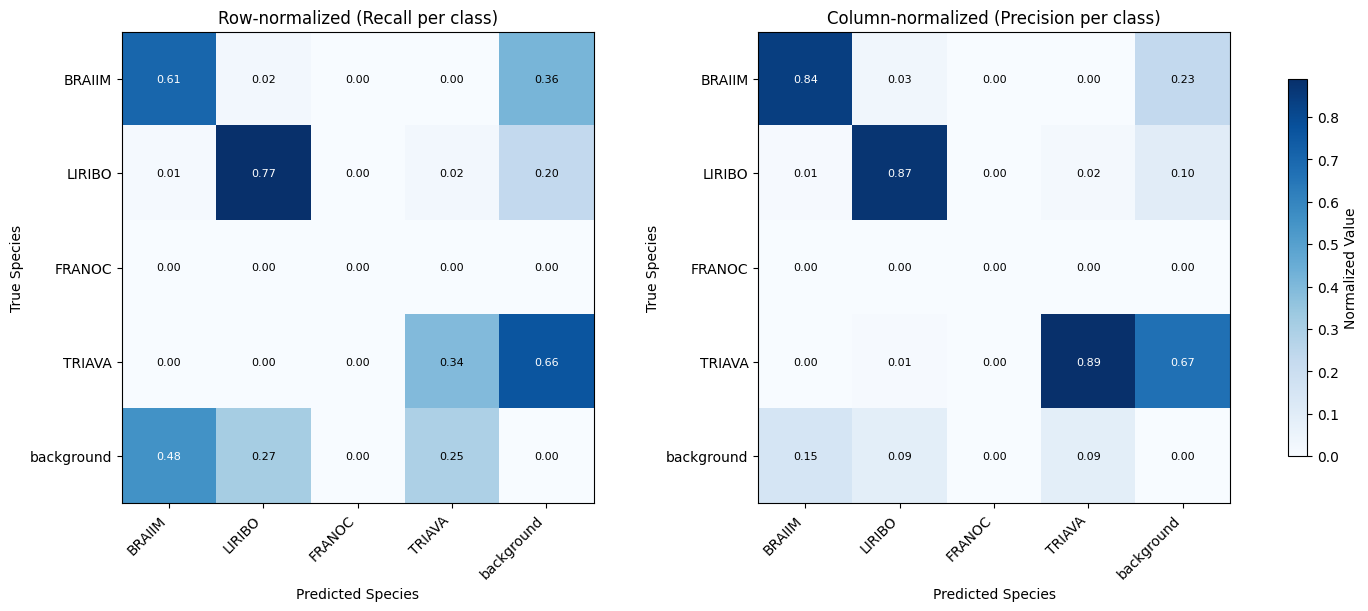

In [ ]:
#test results of second iteration weighted
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/second_iteration_weighted_train4.json"
c1,c2 = give_confusion_infos(file)

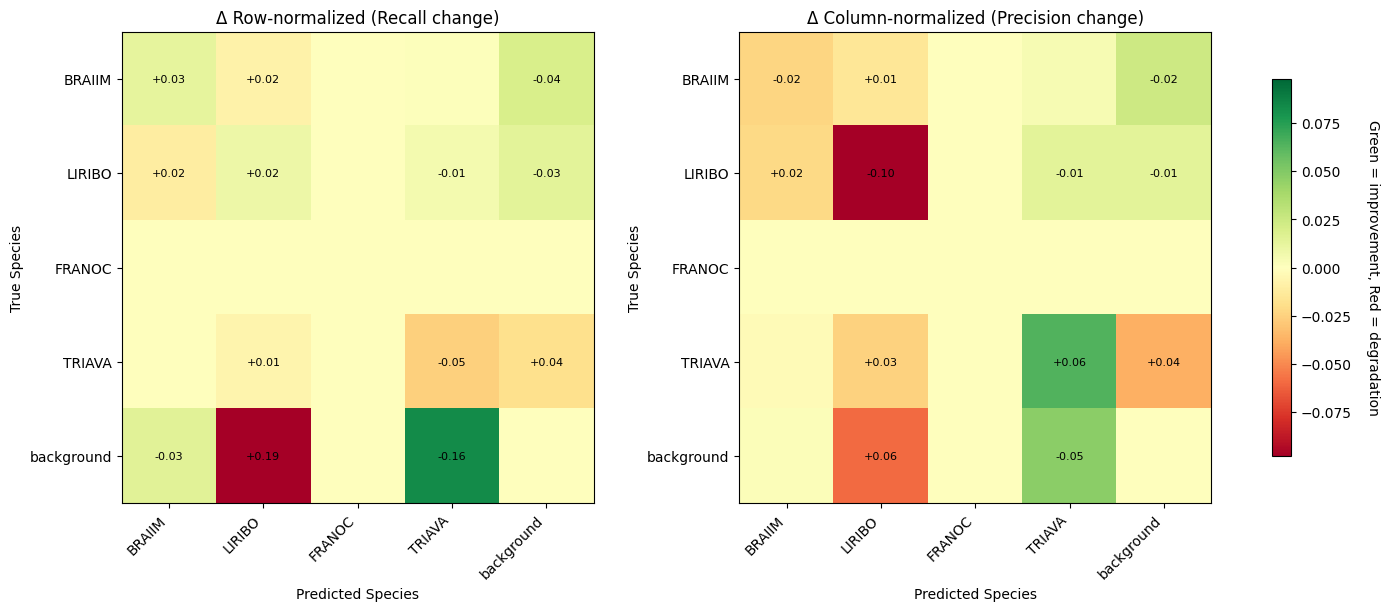

In [ ]:
#Difference of first training and second weighted
plot_confusion_matrix_differences(c1,c3, c2, c4, species, 
                                  output_path="/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/04b_second_vs_first_weighted.png")

### Seems like  a tradeoff between prec/recall

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 961   59    0    6  618]
 [  11 1016    0   13  243]
 [   0    0    0    0    0]
 [   1   14    0  747 1874]
 [ 152  119    0   47    0]]


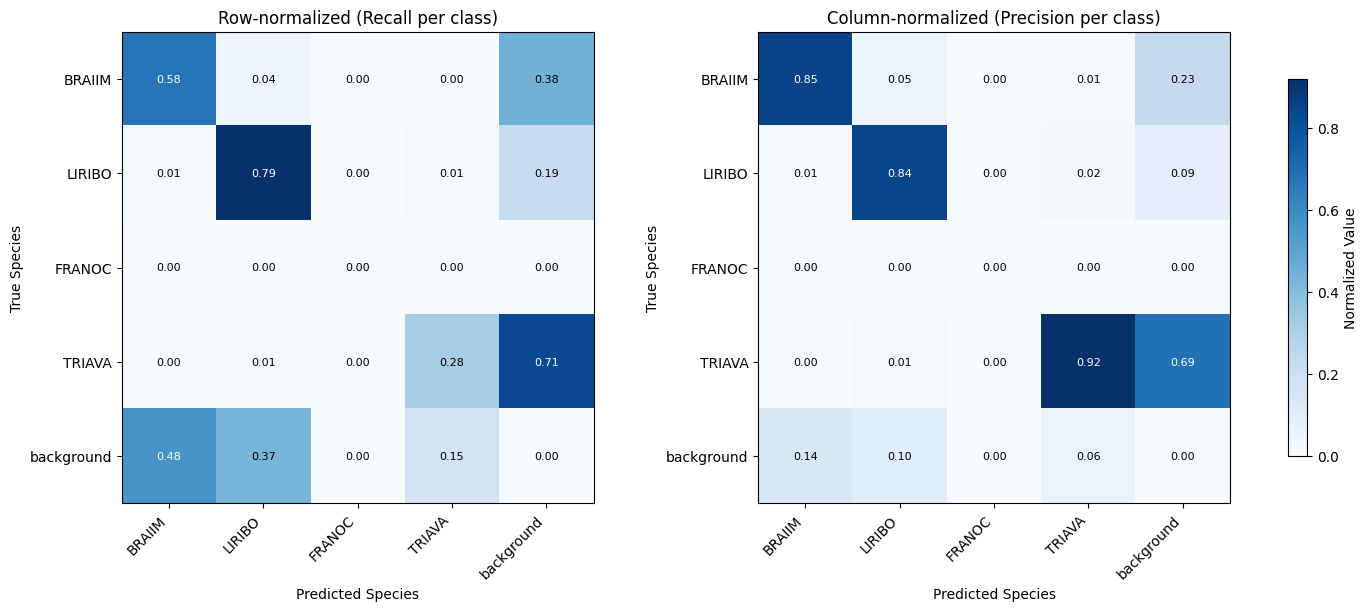

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 990   37    0    4  589]
 [  12  995    0   20  264]
 [   0    0    0    0    0]
 [   1    8    0  894 1727]
 [ 178   98    0   92    0]]


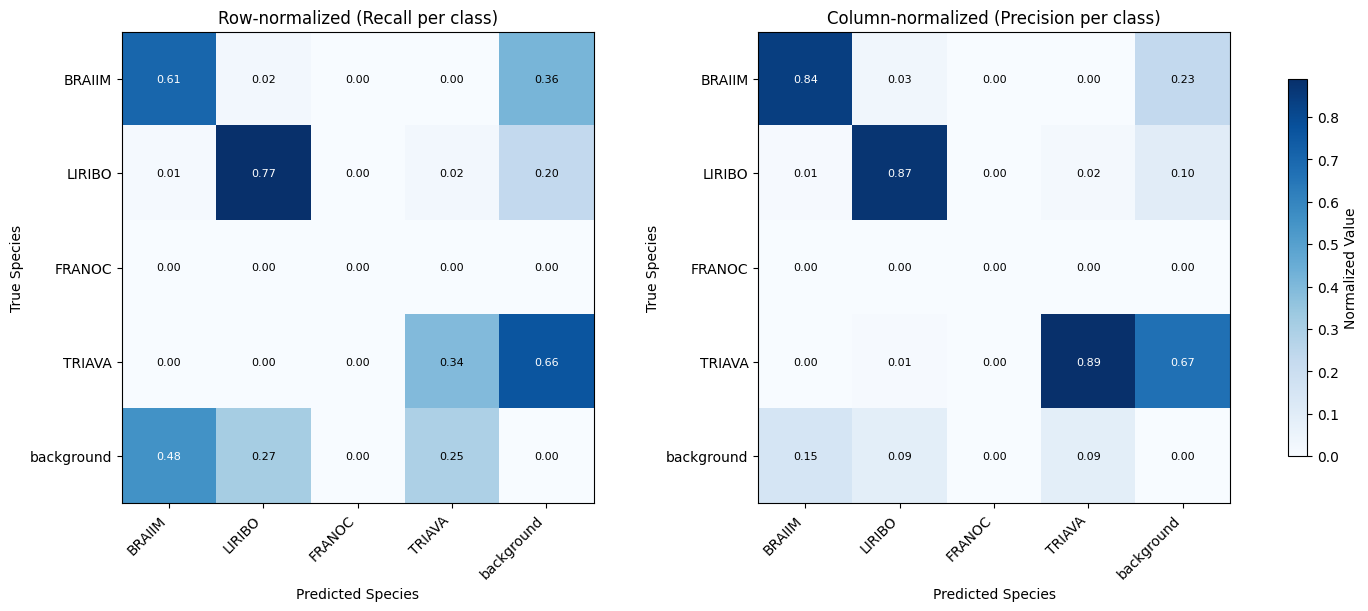

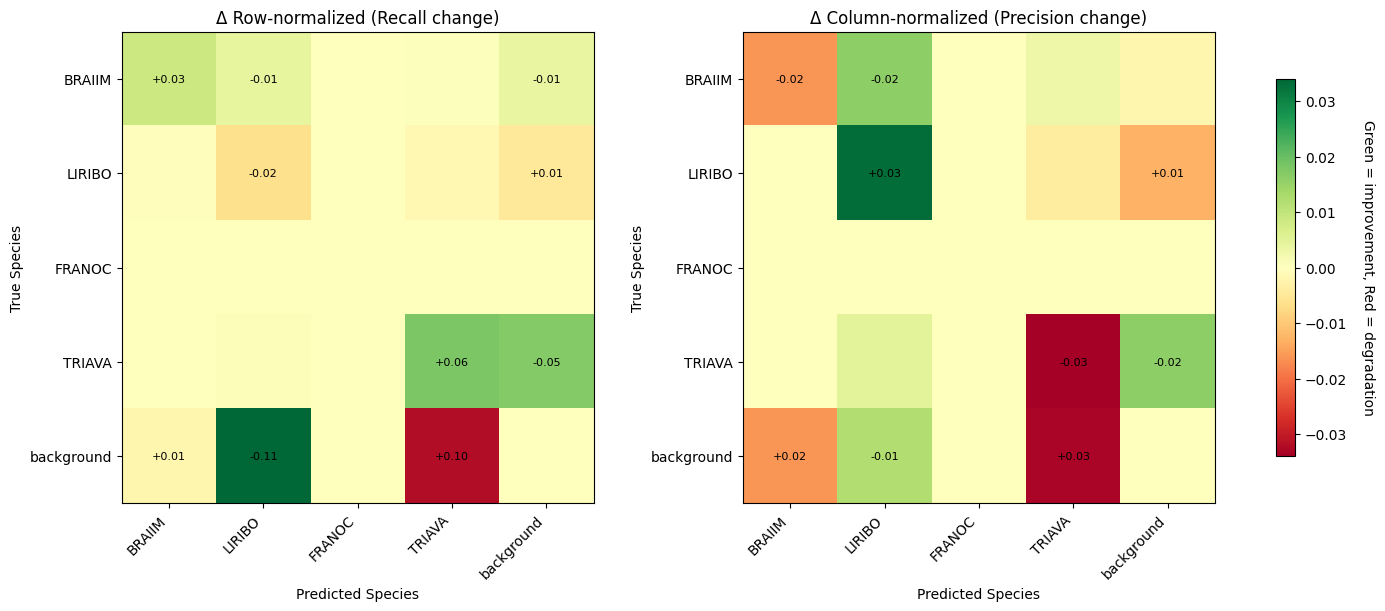

In [ ]:
#differences of second unweighted and weighted
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/second_iteration_unweighted_train1.json"
c1,c2 = give_confusion_infos(file)
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/second_iteration_weighted_train4.json"
c3,c4 = give_confusion_infos(file)
plot_confusion_matrix_differences(c1,c3, c2, c4, species, 
                                  output_path="/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/04c_unweighted_vs_weighted.png")

### More iterations on weighted pseudo labels


Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 896   30    0    2  683]
 [  10  942    0   12  317]
 [   0    0    0    0    0]
 [   1    6    0  735 1886]
 [ 158   85    0   54    0]]


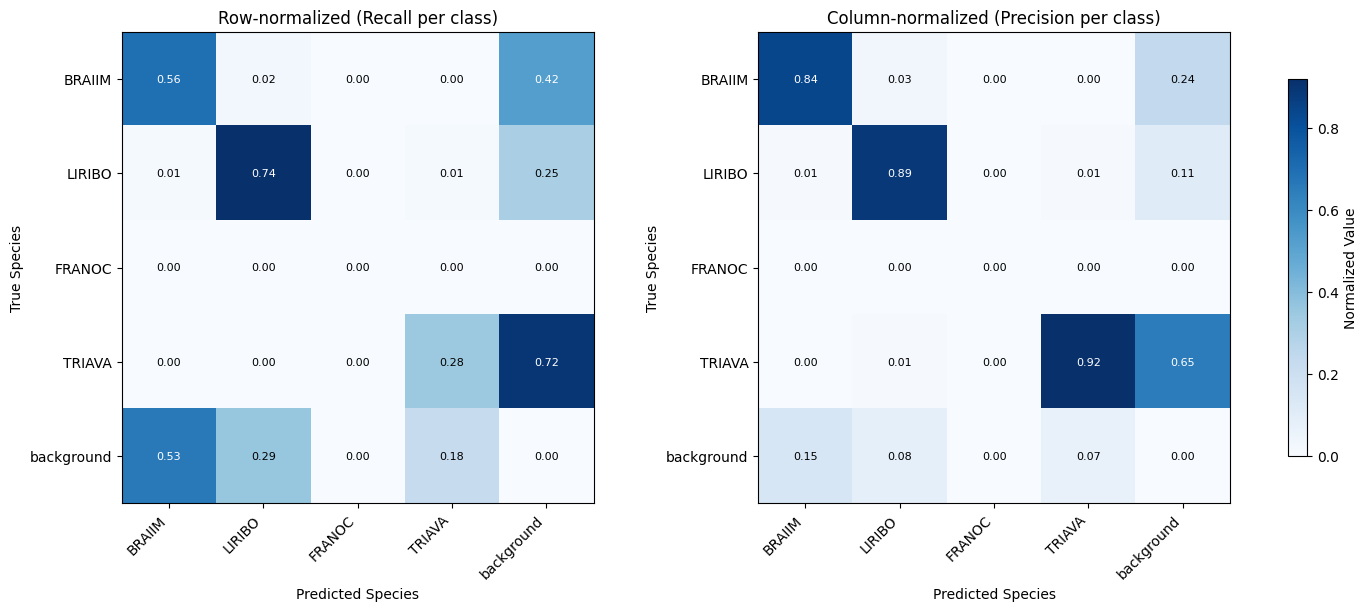

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 780   34    0    5  799]
 [  17  939    0    7  320]
 [   0    0    0    0    0]
 [   2   10    0  617 2004]
 [ 114   92    0   35    0]]


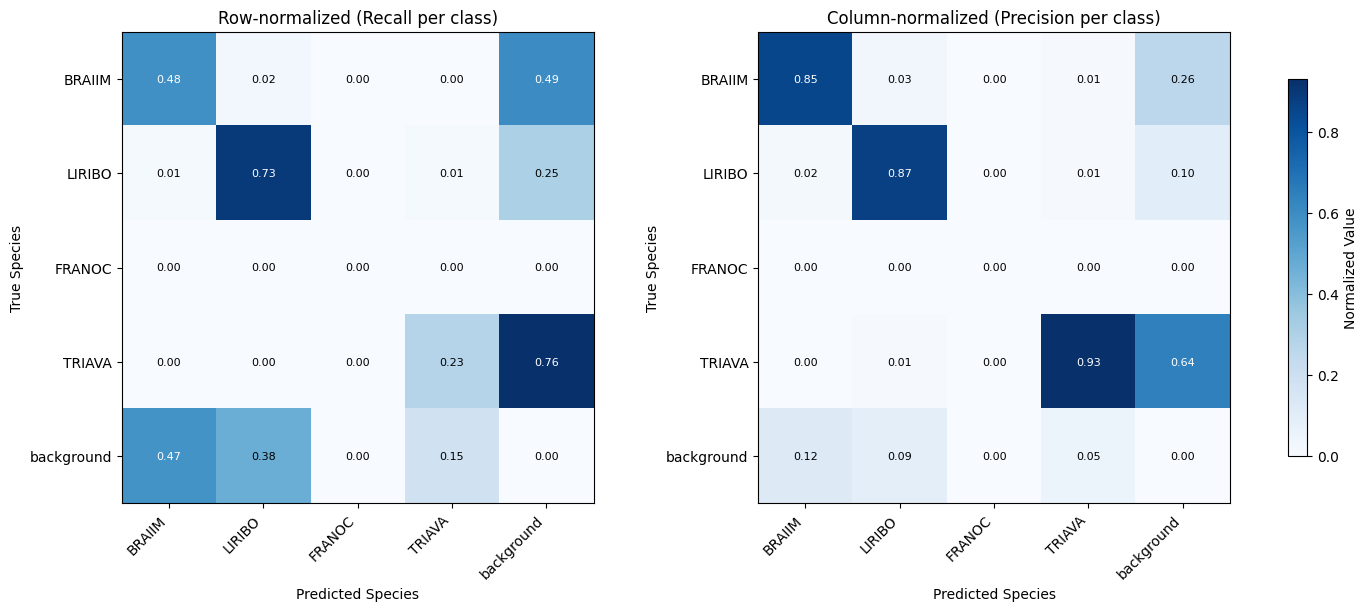

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 930   24    0    6  649]
 [  66  911    0   18  348]
 [   0    0    0    0    0]
 [   1    3    0  694 1927]
 [ 153   80    0   45    0]]


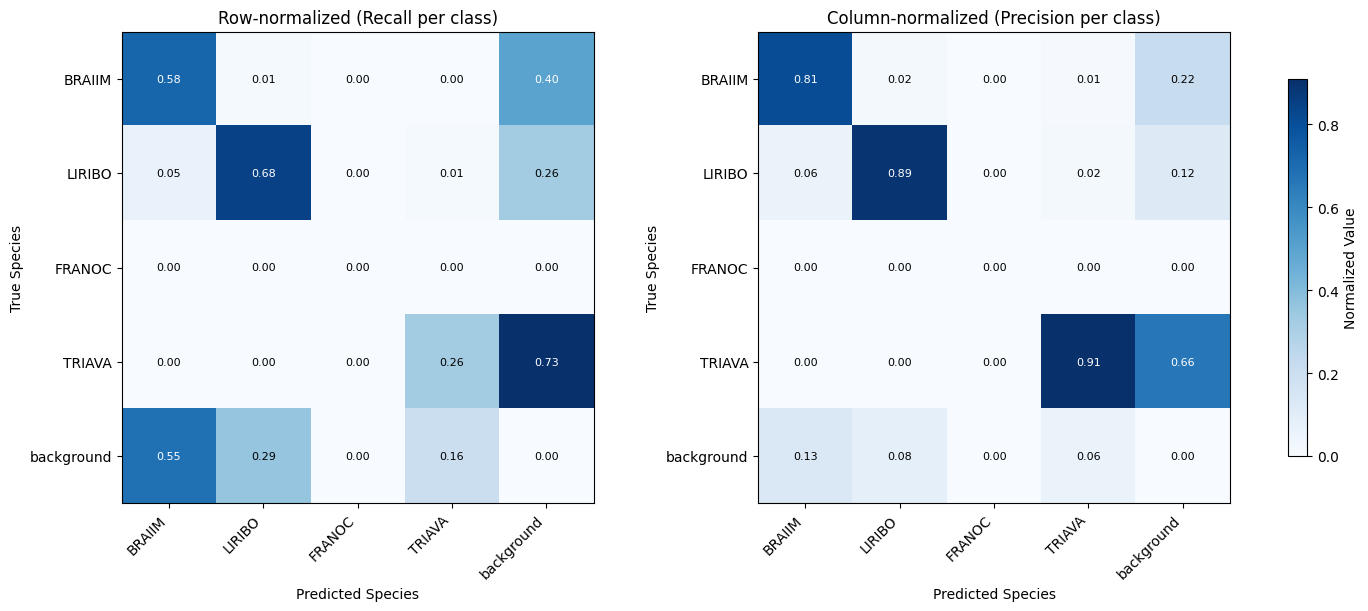

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[ 901   24    0    2  678]
 [  17  890    0   10  369]
 [   0    0    0    0    0]
 [   5    5    0  639 1982]
 [ 156   70    0   31    0]]


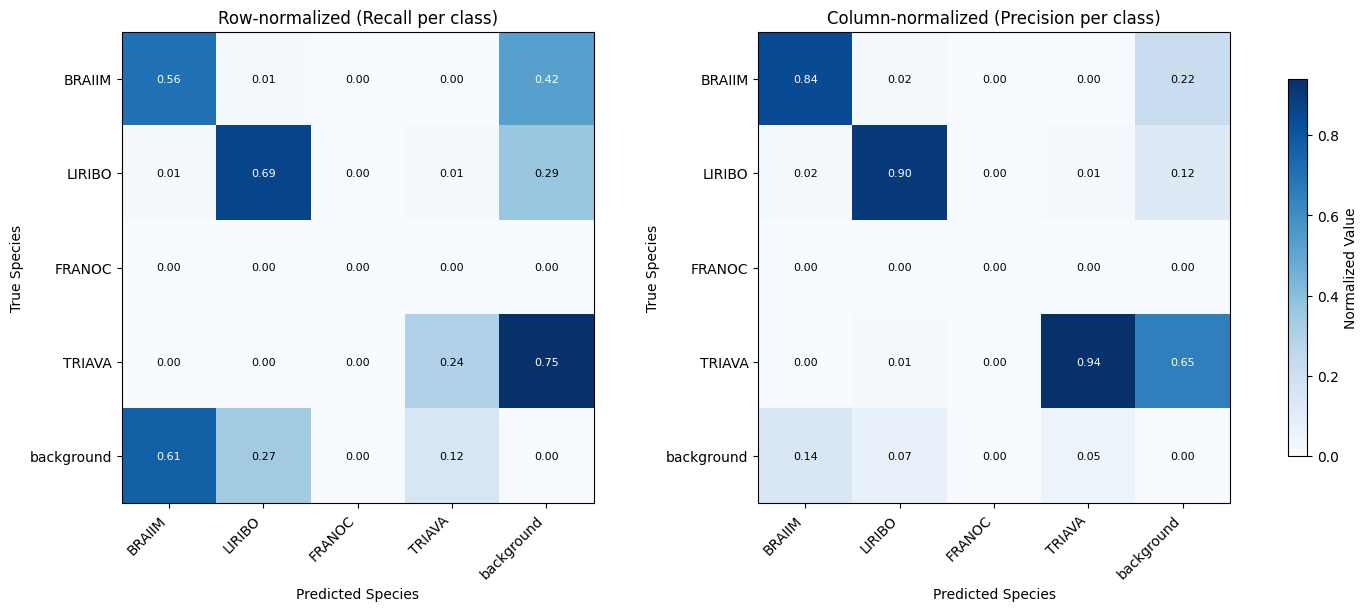

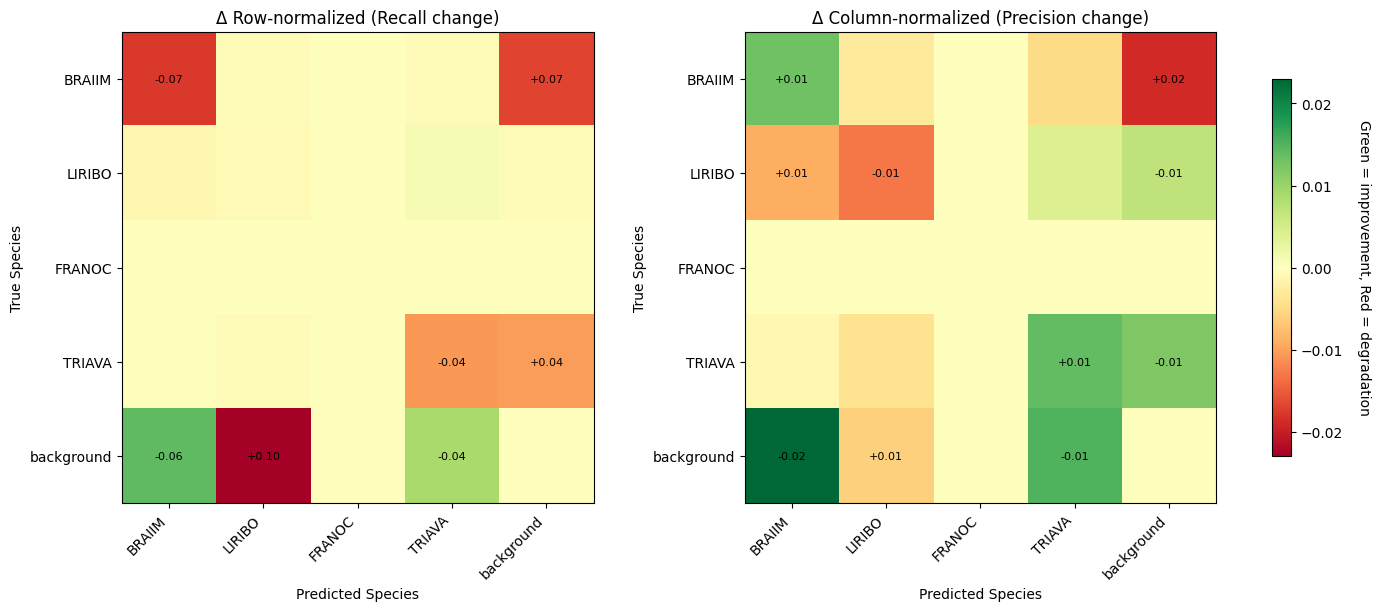

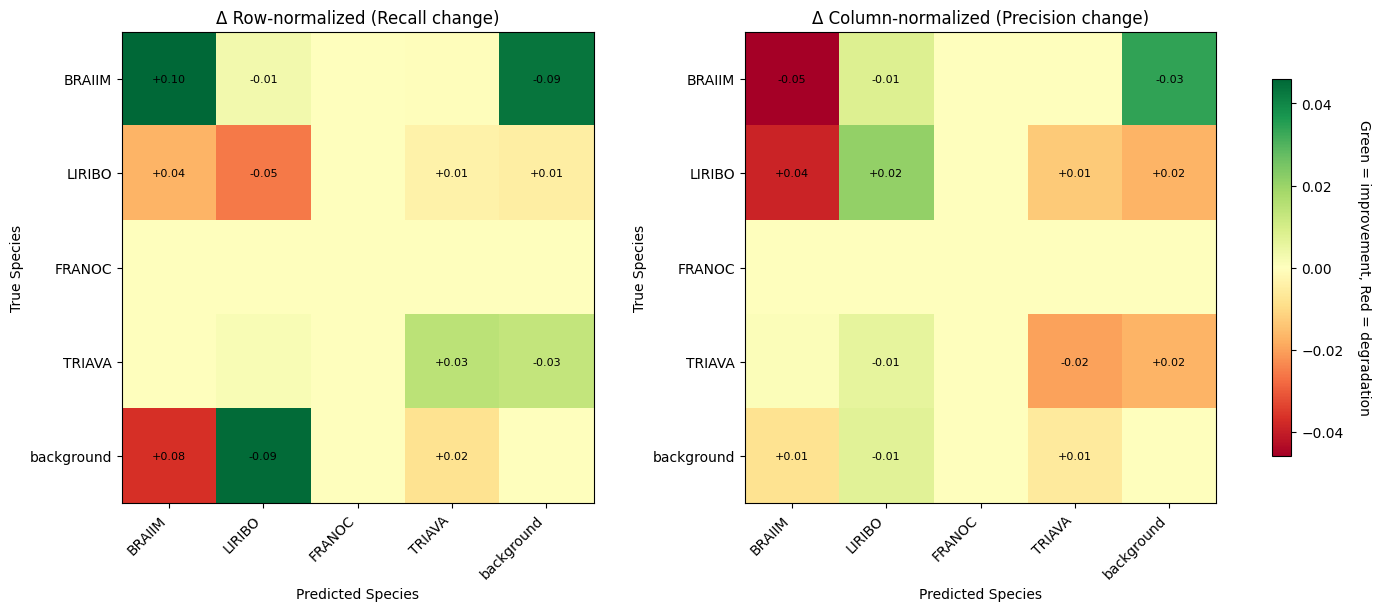

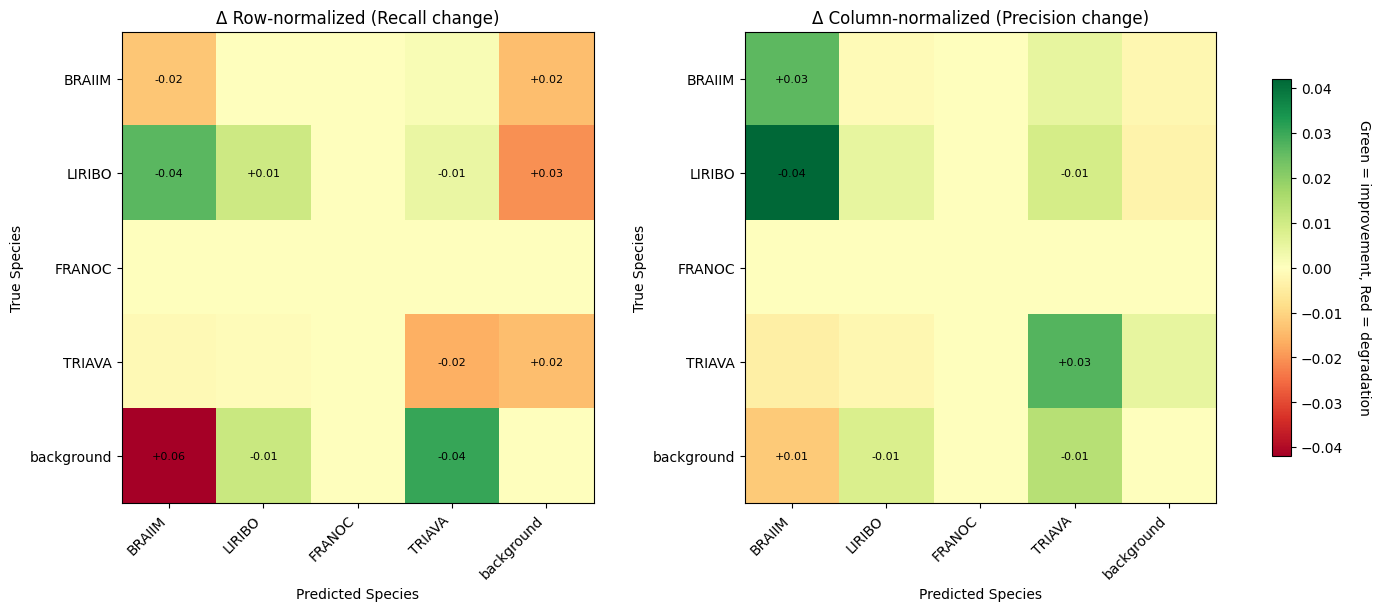

In [25]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/more_iterations1.json"
c1,c2 = give_confusion_infos(file)
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/more_iterations2.json"
c3,c4 = give_confusion_infos(file)
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/more_iterations5.json"
c5,c6 = give_confusion_infos(file)
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/more_iterations6.json"
c7,c8 = give_confusion_infos(file)
plot_confusion_matrix_differences(c1,c3, c2, c4, species)
plot_confusion_matrix_differences(c3,c5, c4, c6, species)
plot_confusion_matrix_differences(c5,c7, c6, c8, species)

### I'd say in the end this did not change anything

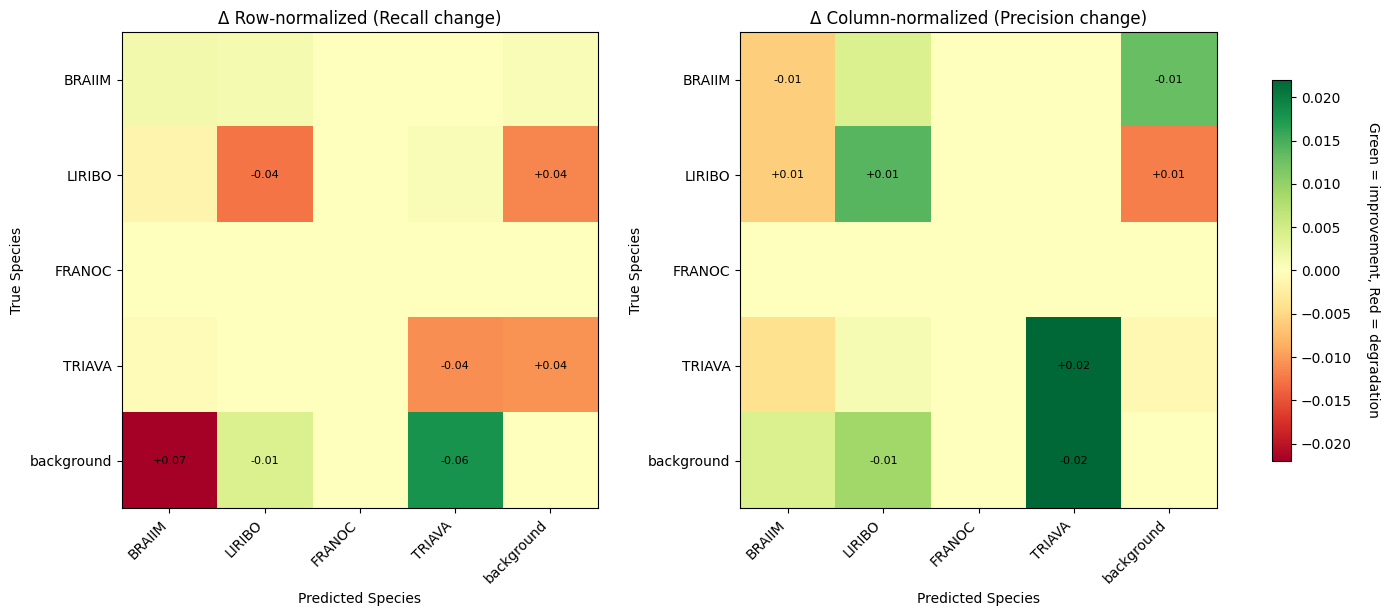

In [26]:
plot_confusion_matrix_differences(c1,c7, c2, c8, species)

### manual tests: fewer labels than supervised, predicting pseudo labels
instant good results

no improvements

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1313   52    0    1  266]
 [  13 1149    0   11  110]
 [   0    0    0    0    0]
 [   0    3    0 2082  539]
 [ 151   58    0  177    0]]


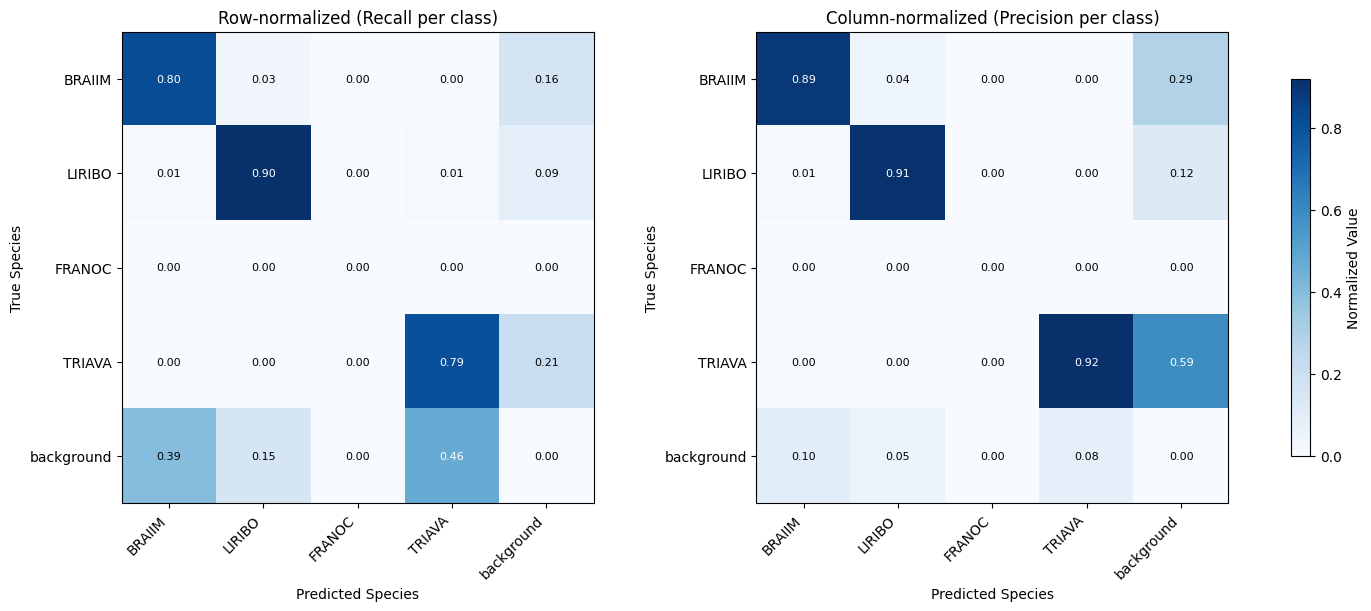

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1213   59    0    1  366]
 [  10 1184    0    7   75]
 [   0    0    0    0    0]
 [   0    2    0 1693  928]
 [  89   62    0   84    0]]


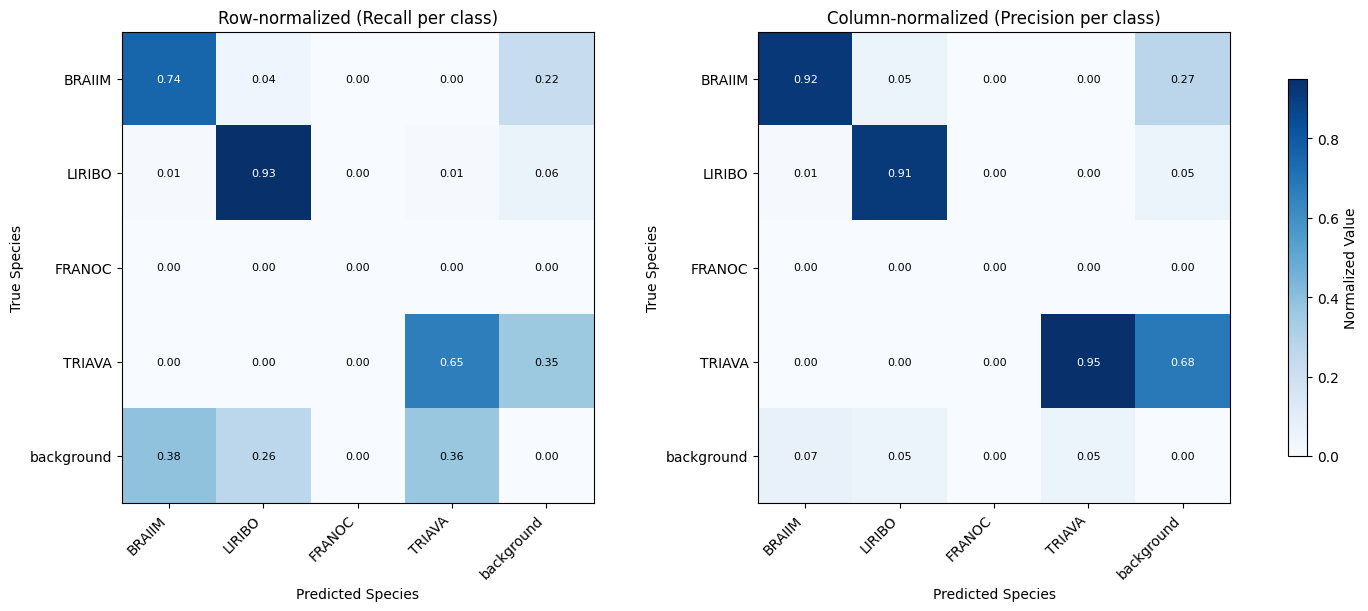

Confusion Matrix with FP/FN (last row = FP, last col = FN):
 [[1232  125    0    0  347]
 [  11 1197    0   10   62]
 [   0    0    0    0    0]
 [   0    5    0 1462 1159]
 [ 126   73    0   56    0]]


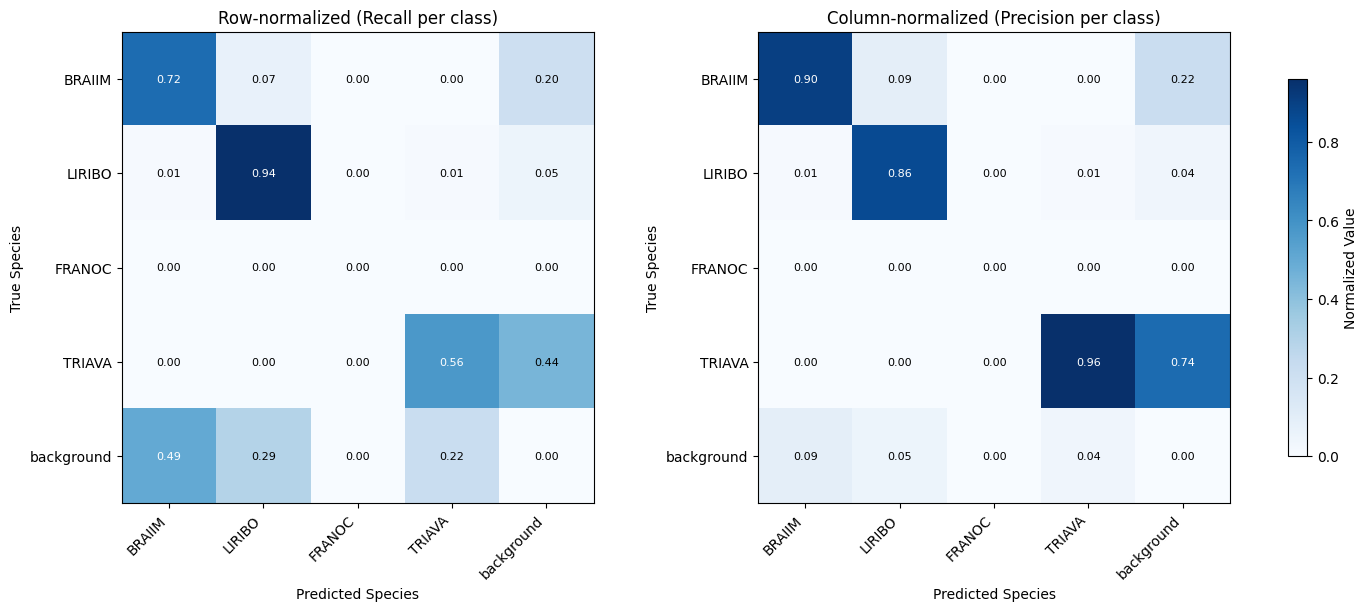

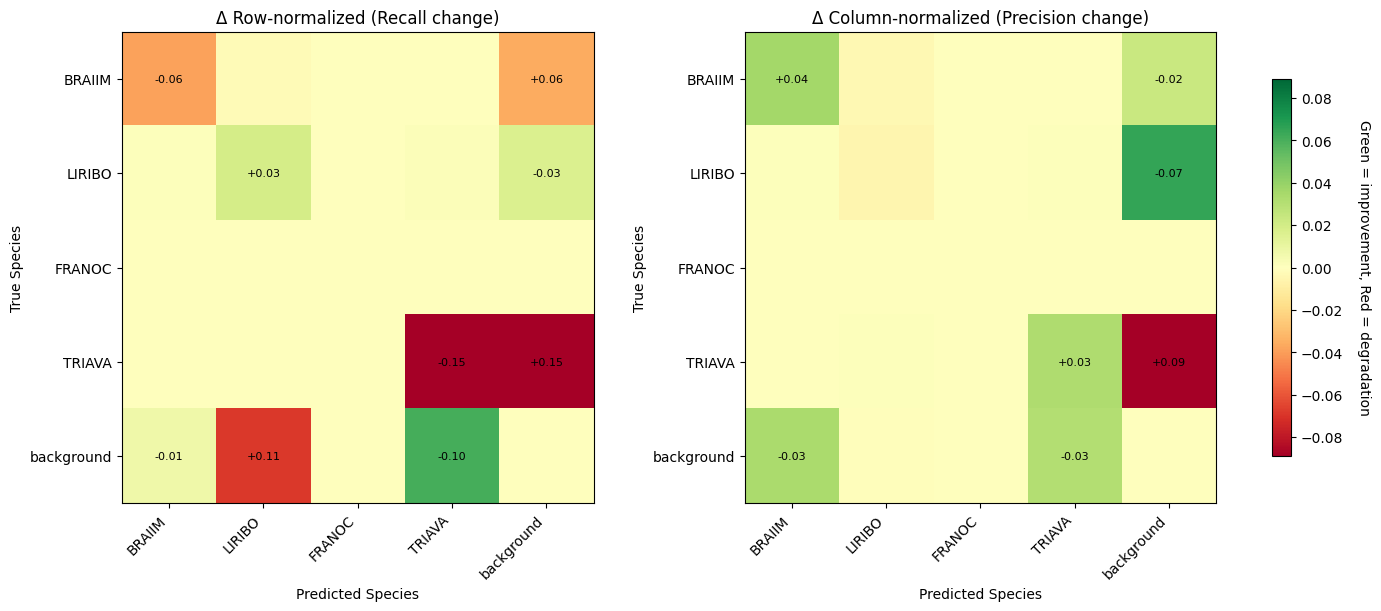

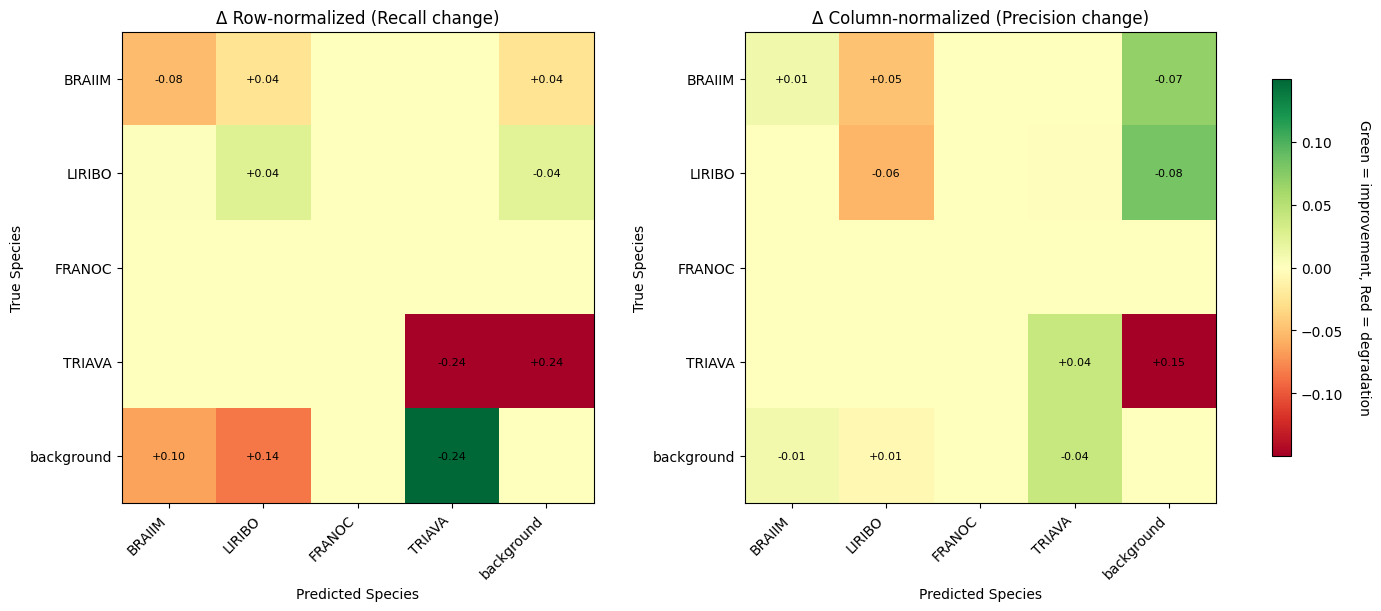

In [5]:
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/manual2.json"
c1,c2 = give_confusion_infos(file, 
                             output_path = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/first_manual.png")
file = "/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/manual3.json"
c3,c4 = give_confusion_infos(file)
file = "//user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results_archive/manual4.json"
c5,c6 = give_confusion_infos(file)
plot_confusion_matrix_differences(c1,c3, c2, c4, species)
plot_confusion_matrix_differences(c1,c5, c2, c6, species)
